###Проект: Прогнозирование цены заказа в онлайн-ритейле
Ссылка на используемый датасет: https://www.kaggle.com/datasets/ertugrulesol/online-retail-data
###Оглавление

1.Описание проекта и бизнес-задачи

2.Импорт библиотек и загрузка данных

3.EDA - Разведочный анализ данных

4.Предобработка данных

5.Кластеризация пользователей

6.Модель регрессии

7.Выводы



###Описание проекта

###Бизнес-задача
Интернет-магазину необходимо:

1.Сегментировать клиентов для персонализации маркетинговых кампаний

2.Прогнозировать цену заказа для планирования логистики и акций

###Целевые метрики
Для кластеризации: Silhouette Score, Inertia

Для регрессии: MAE, RMSE, R²

###План работ
1.EDA (анализ данных)

2.Предобработка (кодирование, масштабирование)

3.Кластеризация (KMeans)

4.Регрессия (RandomForest, XGBoost, LinearRegression)

5.Выводы и рекомендации

###Импорт библиотек и загрузка данных

In [1]:
# Импорт библиотек
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

# Визуализация
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Загрузка данных
import kagglehub

path = kagglehub.dataset_download("ertugrulesol/online-retail-data")
df = pd.read_csv(os.path.join(path, "synthetic_online_retail_data.csv"), encoding="latin-1")

print(f"Размер датасета: {df.shape}")
df.head()

100%|██████████| 25.5k/25.5k [00:00<00:00, 9.43MB/s]

Extracting files...
Размер датасета: (1000, 13)


,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.00,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.00,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.00,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.00,F,33


In [3]:
# Базовая информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   object 
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   object 
 5   product_name    1000 non-null   object 
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   object 
 9   city            1000 non-null   object 
 10  review_score    799 non-null    float64
 11  gender          897 non-null    object 
 12  age             1000 non-null   int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


In [4]:
# Статистическое описание числовых признаков
df.describe()

,customer_id,product_id,category_id,quantity,price,review_score,age
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00",799.00,"1,000.00"
mean,"55,490.72",540.73,30.03,2.95,251.85,3.99,46.38
std,"25,910.19",261.74,14.37,1.41,139.19,1.24,16.57
min,"10,201.00",100.00,10.00,1.00,10.72,1.00,18.00
25%,"33,857.00",311.75,20.00,2.00,128.53,3.00,32.00
50%,"54,619.50",542.50,30.00,3.00,250.22,4.00,47.00
75%,"77,848.50",770.75,40.00,4.00,366.47,5.00,61.00
max,"99,923.00",995.00,50.00,5.00,499.50,5.00,75.00


###Промежуточный вывод по состоянию данных
1.Датасет содержит 1000 записей о транзакциях интернет-магазина;

2.В данных присутствуют пропуски в столбцах 'review_score' (20.1%) и 'gender' (10.3%);


###EDA
###1. Анализ пропусков и качества данных

In [5]:
# Анализ пропусков
missing_df = pd.DataFrame({
    'Кол-во пропусков': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Кол-во пропусков'] > 0])

              Кол-во пропусков  Доля (%)
review_score               201     20.10
gender                     103     10.30


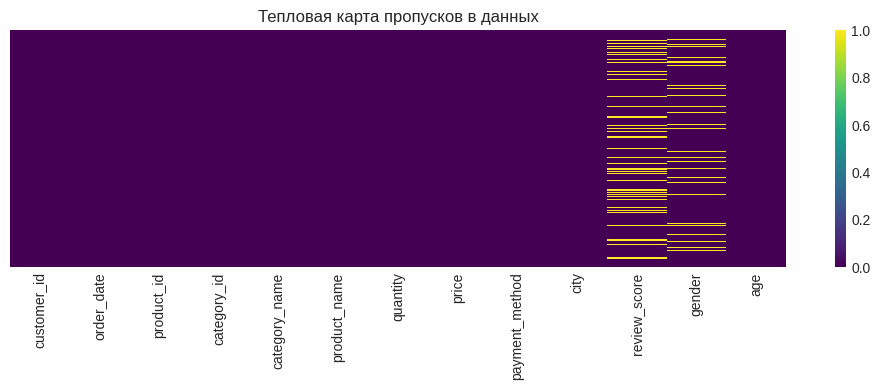

In [6]:
# Визуализация пропусков
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Тепловая карта пропусков в данных')
plt.tight_layout()
plt.show()

Вывод: Пропуски только в столбцах review_score (20.1%) и gender (10.3%).

###2. Анализ целевой переменной (цена заказа)

In [7]:
# Создаем целевую переменную - стоимость заказа
df['order_value'] = df['quantity'] * df['price']

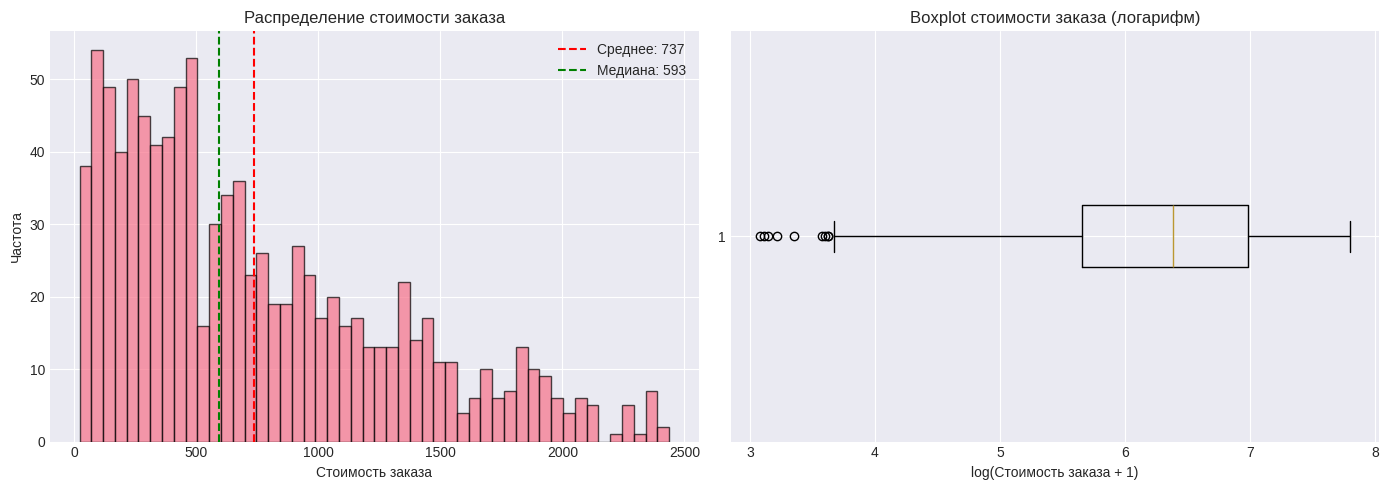

Средняя стоимость заказа: 737.33
Медианная стоимость заказа: 592.79
Стандартное отклонение: 566.40


In [8]:
# Распределение стоимости заказа
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df['order_value'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Стоимость заказа')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение стоимости заказа')
axes[0].axvline(df['order_value'].mean(), color='red', linestyle='--', label=f'Среднее: {df["order_value"].mean():.0f}')
axes[0].axvline(df['order_value'].median(), color='green', linestyle='--', label=f'Медиана: {df["order_value"].median():.0f}')
axes[0].legend()

# Boxplot (после логарифмирования для лучшей визуализации)
axes[1].boxplot(np.log1p(df['order_value']), vert=False)
axes[1].set_xlabel('log(Стоимость заказа + 1)')
axes[1].set_title('Boxplot стоимости заказа (логарифм)')

plt.tight_layout()
plt.show()

print(f"Средняя стоимость заказа: {df['order_value'].mean():.2f}")
print(f"Медианная стоимость заказа: {df['order_value'].median():.2f}")
print(f"Стандартное отклонение: {df['order_value'].std():.2f}")

###Промежуточный вывод по стоимости заказов

Большинство заказов сосредоточено в диапазоне небольших значений;

Присутствуют дорогие заказы-выбросы, которые увеличивают среднее значение.



###3. Анализ клиентов

In [9]:
# Уникальные клиенты
unique_customers = df['customer_id'].nunique()
print(f"Количество уникальных клиентов: {unique_customers}")
print(f"Среднее количество заказов на клиента: {len(df) / unique_customers:.2f}")

Количество уникальных клиентов: 1000
Среднее количество заказов на клиента: 1.00


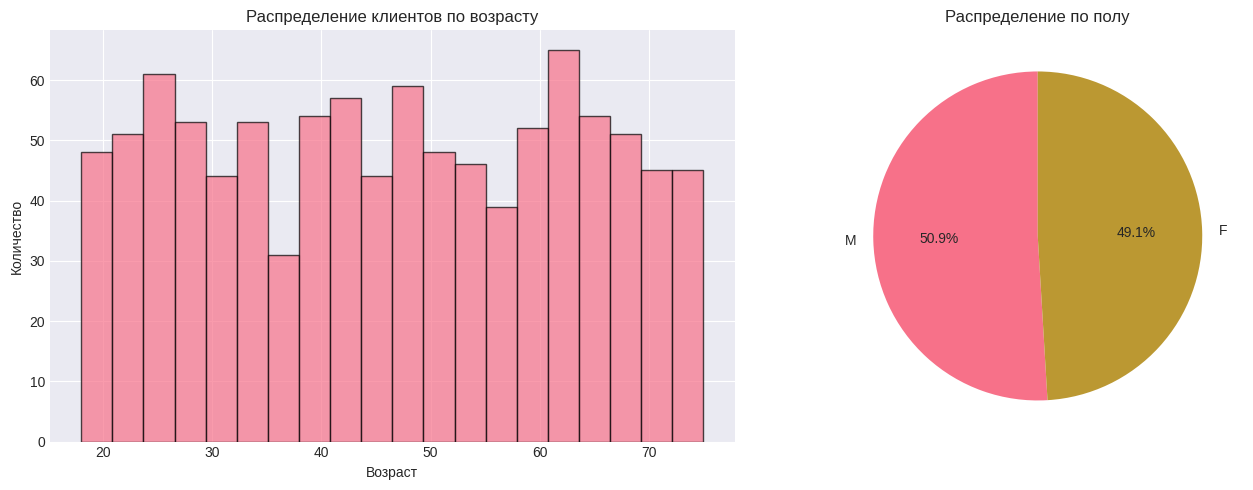

In [10]:
# Распределение по возрасту и полу
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение возраста
axes[0].hist(df['age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение клиентов по возрасту')

# Распределение по полу
gender_counts = df['gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Распределение по полу')

plt.tight_layout()
plt.show()

In [11]:
# Возрастные группы
bins = [18, 30, 45, 60, 100]
labels = ['18-29', '30-44', '45-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_group_stats = df.groupby('age_group', observed=True).agg({
    'customer_id': 'nunique',
    'order_value': ['mean', 'median', 'count']
}).round(2)

print(age_group_stats)

          customer_id order_value             
              nunique        mean median count
age_group                                     
18-29             213      722.62 602.20   213
30-44             261      705.57 545.66   261
45-59             247      776.93 656.20   247
60+               279      743.21 600.10   279


###Промежуточный вывод по демографическим признакам

Клиенты в целом равномерно распределены по возрасту за исключением двух возрастных групп: 18-22 и 75-79;

Лидируют по количеству клиентов группы 60-64 (104 человека) и 25-29 (94 человека);

Клиенты равномерно распределены по полу

Средний возраст клиента составляет 45 лет.

###4. Анализ категорий товаров

In [12]:
# Выручка по категориям
category_revenue = df.groupby('category_name')['order_value'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
category_revenue.columns = ['Общая выручка', 'Средний чек', 'Количество продаж']
print(category_revenue)

                    Общая выручка  Средний чек  Количество продаж
category_name                                                    
Electronics            166,510.34       804.40                207
Sports & Outdoors      154,346.26       731.50                211
Books & Stationery     143,215.52       742.05                193
Home & Living          138,540.15       725.34                191
Fashion                134,714.61       680.38                198


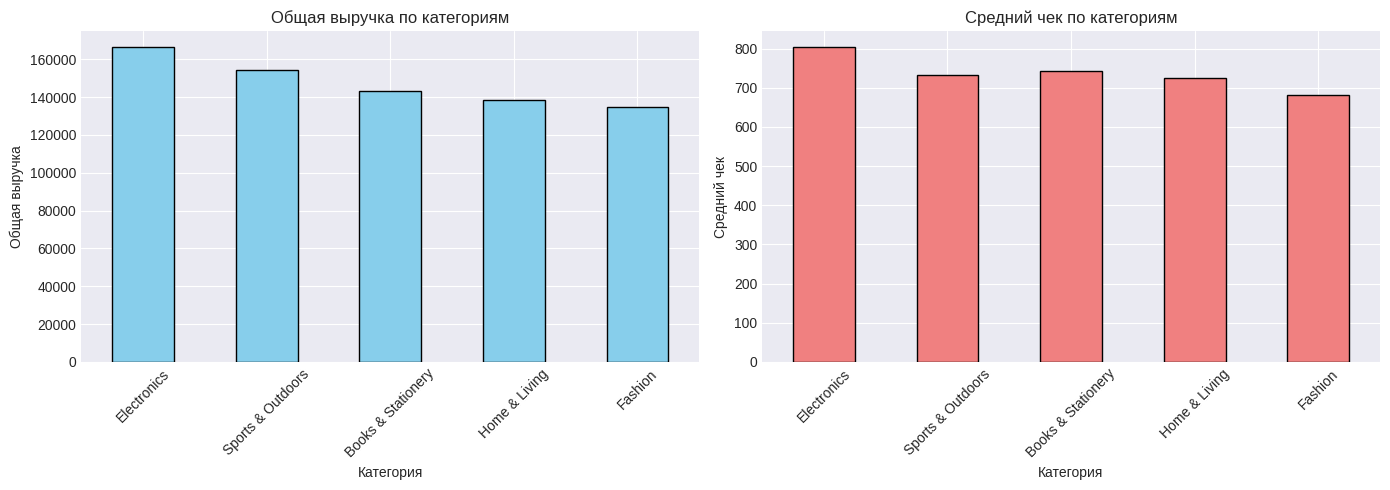

In [13]:
# Визуализация выручки по категориям
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Общая выручка
category_revenue['Общая выручка'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Общая выручка')
axes[0].set_title('Общая выручка по категориям')
axes[0].tick_params(axis='x', rotation=45)

# Средний чек
category_revenue['Средний чек'].plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Средний чек')
axes[1].set_title('Средний чек по категориям')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

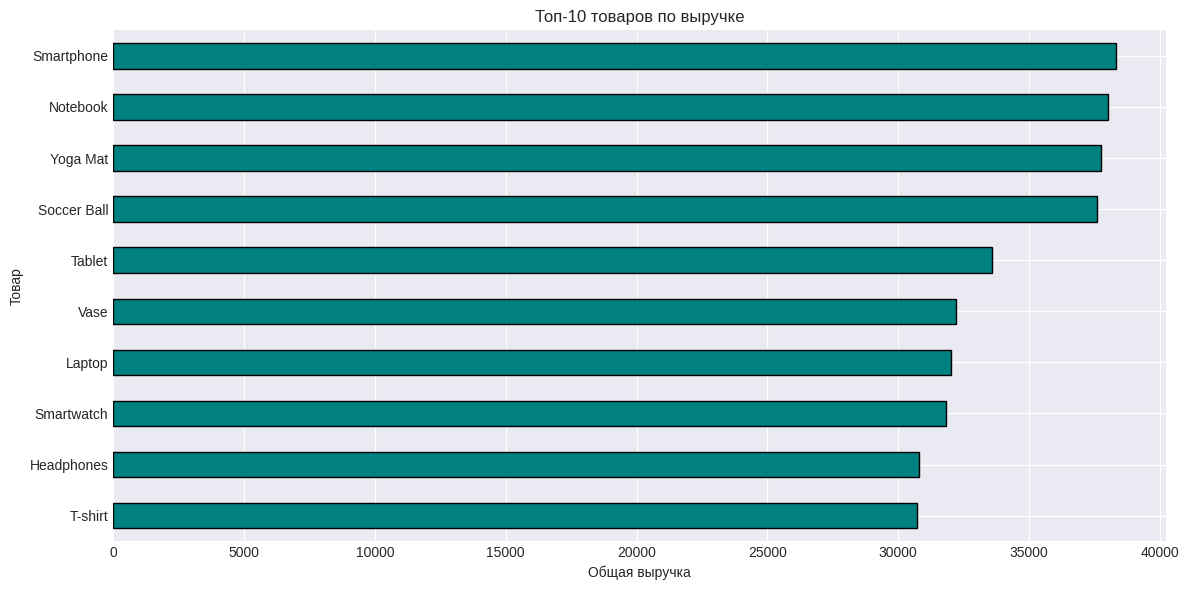

In [14]:
# Топ-10 товаров по выручке
top_products = df.groupby('product_name')['order_value'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Общая выручка')
plt.ylabel('Товар')
plt.title('Топ-10 товаров по выручке')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###Промежуточный вывод по категориям товаров

Категория "Электроника" лидирует по общей выручке (26.5% от всей выручки);

На втором месте категория "Спорт и активный отдых" (24.6% выручки);

На третьем месте категория "Книги и канцелярия" (22.8% выручки);

Категория "Одежда" показывает наименьшую выручку среди всех категорий.

###5. Анализ способов оплаты

In [15]:
# Анализ способов оплаты
payment_stats = df.groupby('payment_method').agg({
    'order_value': ['count', 'mean', 'median', 'sum'],
    'review_score': 'mean'
}).round(2)

payment_stats.columns = ['Количество', 'Средний чек', 'Медианный чек', 'Общая выручка', 'Средняя оценка']
print(payment_stats)

                  Количество  Средний чек  Медианный чек  Общая выручка  \
payment_method                                                            
Bank Transfer            322       729.36         586.57     234,853.69   
Cash on Delivery         374       733.62         594.08     274,375.64   
Credit Card              304       750.32         593.33     228,097.55   

                  Средняя оценка  
payment_method                    
Bank Transfer               4.05  
Cash on Delivery            3.97  
Credit Card                 3.96  


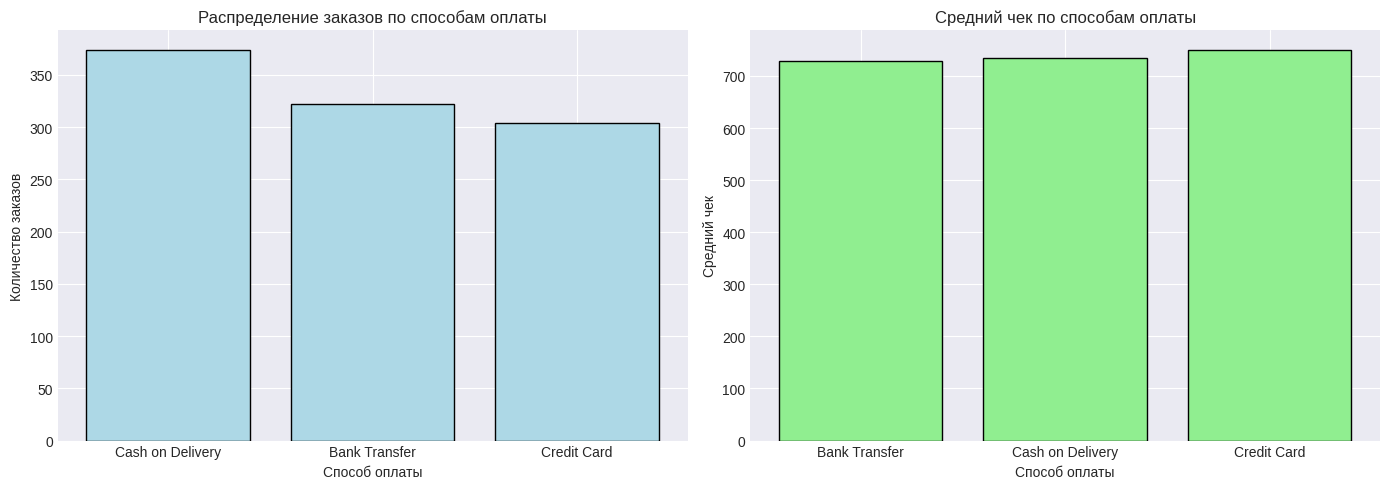

In [16]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество заказов
payment_counts = df['payment_method'].value_counts()
axes[0].bar(payment_counts.index, payment_counts.values, color='lightblue', edgecolor='black')
axes[0].set_xlabel('Способ оплаты')
axes[0].set_ylabel('Количество заказов')
axes[0].set_title('Распределение заказов по способам оплаты')

# Средний чек
avg_payment = df.groupby('payment_method')['order_value'].mean()
axes[1].bar(avg_payment.index, avg_payment.values, color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Способ оплаты')
axes[1].set_ylabel('Средний чек')
axes[1].set_title('Средний чек по способам оплаты')

plt.tight_layout()
plt.show()

###Промежуточный вывод по способам оплаты

Все три способа оплаты используются примерно одинаково часто (32-38% каждый);

Средний чек незначительно отличается между способами оплаты (728-750 единиц);

Средние оценки по всем способам оплаты близки (около 4 баллов из 5);

Оплата наличными встречается немного чаще (37.4% заказов).

###6. Анализ временных факторов

In [17]:
# Преобразование даты
df['order_date'] = pd.to_datetime(df['order_date'])
df['day_of_week'] = df['order_date'].dt.day_name()
df['month'] = df['order_date'].dt.month_name()
df['hour'] = df['order_date'].dt.hour

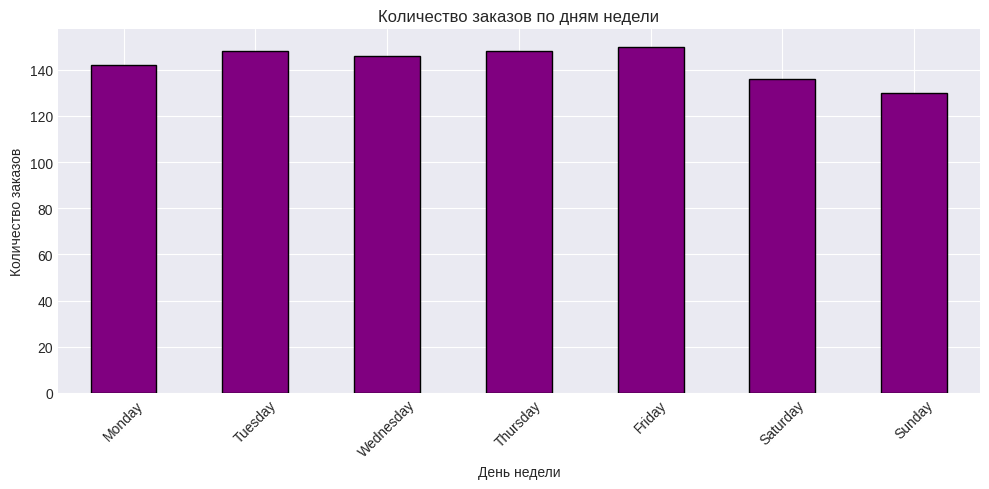

In [18]:
# Заказы по дням недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
daily_orders.plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.title('Количество заказов по дням недели')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

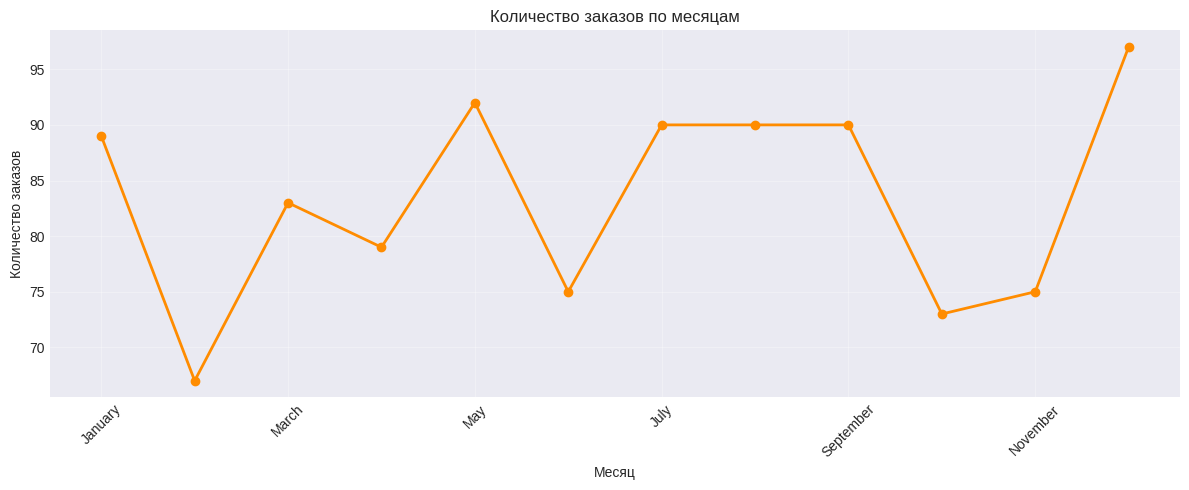

In [19]:
# Заказы по месяцам
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_orders = df['month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='darkorange', linewidth=2)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.title('Количество заказов по месяцам')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###7. Анализ оценок

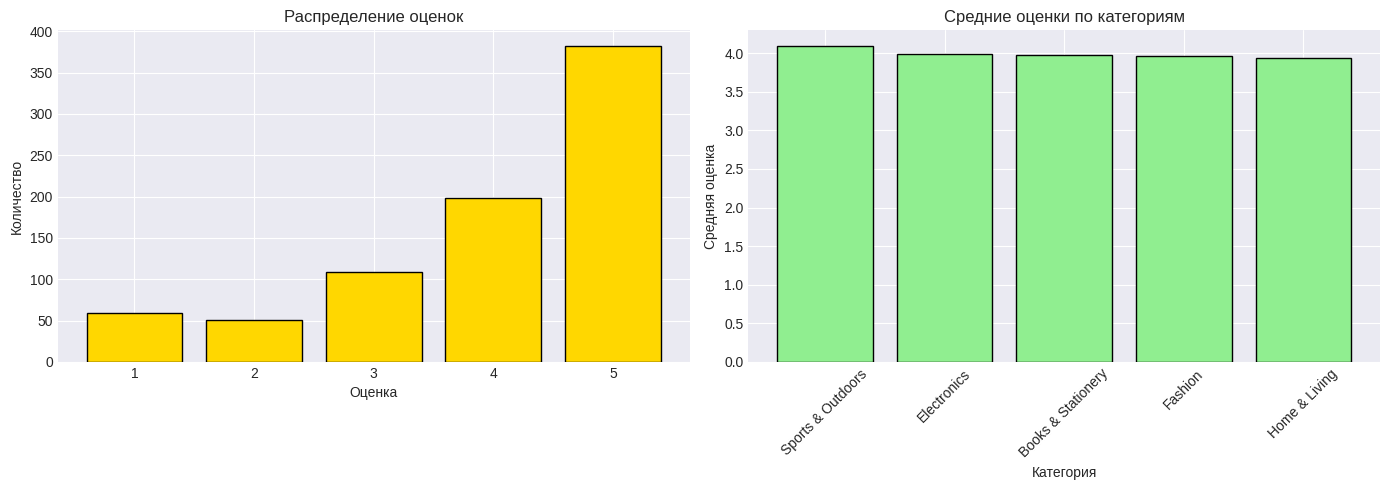

Средняя оценка: 3.99


In [20]:
# Распределение оценок
score_counts = df['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].bar(score_counts.index, score_counts.values, color='gold', edgecolor='black')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение оценок')

# Средние оценки по категориям
category_scores = df.groupby('category_name')['review_score'].mean().sort_values(ascending=False)
axes[1].bar(category_scores.index, category_scores.values, color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Средняя оценка')
axes[1].set_title('Средние оценки по категориям')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Средняя оценка: {df['review_score'].mean():.2f}")

###Промежуточный вывод по распределению оценок

Более 75% всех заказов имеют хорошую оценку 4 или 5 (781 заказ);

Количество заказов с плохими оценками 1 и 2 сильно меньше (110 заказов, около 11%);

Средняя оценка по всем товарам составляет 4.1 балла;

Категория "Спорт" имеет самую высокую среднюю оценку (4.29);

Категория "Товары для дома" имеет самую высокую долю низких оценок (13.1%).

###8. Корреляционный анализ

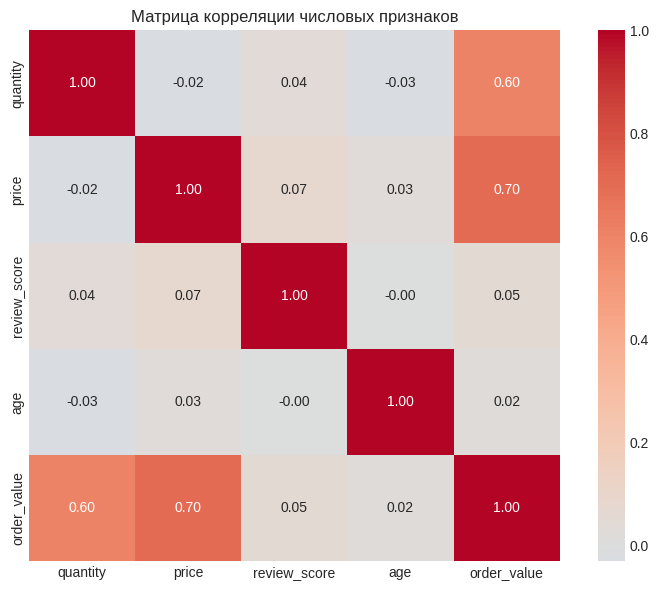

In [21]:
# Выбор числовых признаков для корреляции
numeric_cols = ['quantity', 'price', 'review_score', 'age', 'order_value']

# Расчет корреляции
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Матрица корреляции числовых признаков')
plt.tight_layout()
plt.show()

###Промежуточный вывод по корреляциям

Ожидаемо сильная корреляция между ценой и стоимостью заказа

Возраст клиента практически не коррелирует с другими признаками;

Оценка товара слабо связана с ценой и количеством;


###EDA Выводы
Данные: 1000 записей, пропуски в review_score (20%) и gender (10%)

Клиенты: преобладают возрастные группы 60-64 и 25-29 лет, распределение по полу равномерное

Категории: "Электроника" лидирует по выручке, "Спорт" - по средней оценке

Оплата: три способа оплаты примерно равно популярны, средний чек ~730-750

Время: больше заказов в будни, пик в декабре и январе

###Предобработка данных

In [22]:
# Создаем копию данных для моделирования
df_model = df.copy()

###1. Обработка пропусков

In [23]:
# Заполнение пропусков в gender
df_model['gender'] = df_model['gender'].fillna('Unknown')

# Заполнение пропусков в review_score медианой по категории
df_model['review_score'] = df_model.groupby('category_name')['review_score'].transform(
    lambda x: x.fillna(x.median())
)

###2. Создание признаков

In [24]:
# Временные признаки
df_model['order_year'] = df_model['order_date'].dt.year
df_model['order_month'] = df_model['order_date'].dt.month
df_model['order_day'] = df_model['order_date'].dt.day
df_model['order_dayofweek'] = df_model['order_date'].dt.dayofweek
df_model['order_is_weekend'] = (df_model['order_dayofweek'] >= 5).astype(int)

# Агрегированные признаки на уровне клиента
customer_features = df_model.groupby('customer_id').agg({
    'order_value': ['count', 'mean', 'std', 'sum'],
    'review_score': 'mean',
    'age': 'first',
    'gender': 'first'
}).round(2)

# Сброс индекса
customer_features.columns = ['order_count', 'avg_order_value', 'std_order_value', 'total_spent',
                              'avg_review_score', 'age', 'gender']
customer_features = customer_features.reset_index()

# Заполнение NaN в std
customer_features['std_order_value'] = customer_features['std_order_value'].fillna(0)

print(f"Количество уникальных клиентов для модели: {len(customer_features)}")

Количество уникальных клиентов для модели: 1000


###3. Кодирование категориальных признаков

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Кодирование категориальных признаков
categorical_cols = ['gender']

le = LabelEncoder()
for col in categorical_cols:
    customer_features[col + '_encoded'] = le.fit_transform(customer_features[col].astype(str))

# Выбор признаков для моделирования
feature_cols = ['order_count', 'avg_order_value', 'std_order_value', 'total_spent',
                'avg_review_score', 'age', 'gender_encoded']

X = customer_features[feature_cols]

###4. Масштабирование признаков

In [26]:
# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###Кластеризация пользователей
###1. Определение оптимального числа кластеров

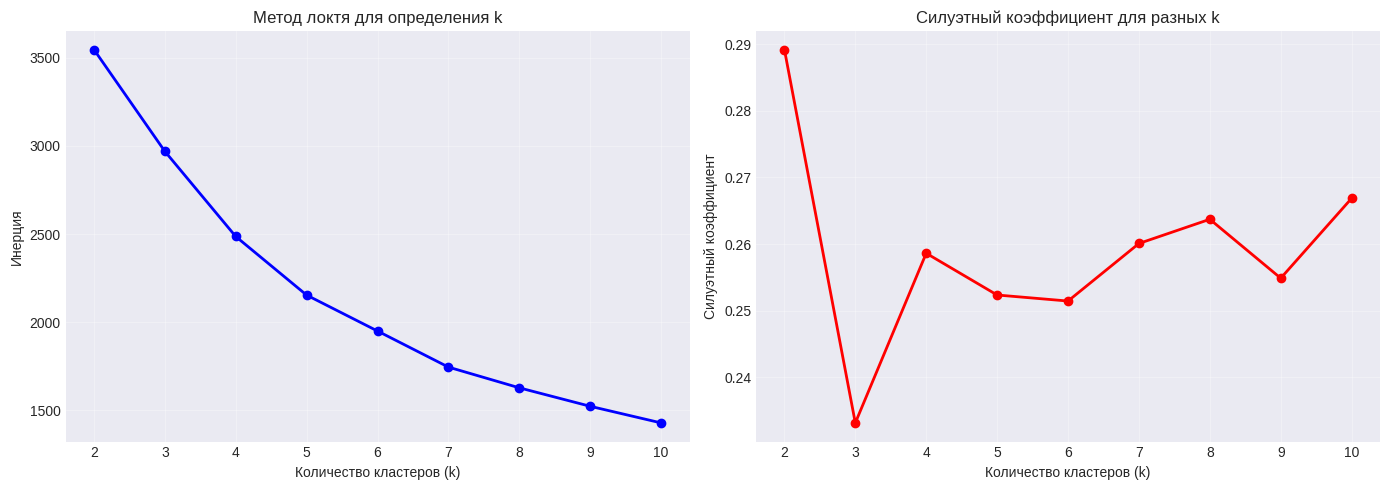

Оптимальное количество кластеров по силуэтному коэффициенту: 2
Силуэтный коэффициент для k=2: 0.289


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Поиск оптимального k
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Метод локтя
axes[0].plot(K_range, inertia, 'bo-', linewidth=2)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция')
axes[0].set_title('Метод локтя для определения k')
axes[0].grid(True, alpha=0.3)

# Силуэтный коэффициент
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Силуэтный коэффициент')
axes[1].set_title('Силуэтный коэффициент для разных k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выбор оптимального k (лучший silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по силуэтному коэффициенту: {optimal_k}")
print(f"Силуэтный коэффициент для k={optimal_k}: {max(silhouette_scores):.3f}")

###2. Обучение модели кластеризации

In [28]:
# Обучение с оптимальным k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
customer_features['cluster'] = kmeans_final.fit_predict(X_scaled)

# Силуэтный коэффициент на итоговой модели
final_silhouette = silhouette_score(X_scaled, customer_features['cluster'])
print(f"Итоговый силуэтный коэффициент: {final_silhouette:.3f}")

Итоговый силуэтный коэффициент: 0.289


###3. Анализ кластеров

In [29]:
# Профили кластеров
cluster_profiles = customer_features.groupby('cluster').agg({
    'order_count': 'mean',
    'avg_order_value': 'mean',
    'total_spent': 'mean',
    'avg_review_score': 'mean',
    'age': 'mean',
    'gender': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).round(2)

# Добавление количества клиентов
cluster_profiles['size'] = customer_features['cluster'].value_counts().sort_index().values

print("Профили кластеров:")
print(cluster_profiles)

Профили кластеров:
         order_count  avg_order_value  total_spent  avg_review_score   age  \
cluster                                                                      
0               1.00           414.90       414.90              3.99 45.94   
1               1.00         1,454.99     1,454.99              4.15 47.36   

        gender  size  
cluster               
0            M   690  
1            F   310  


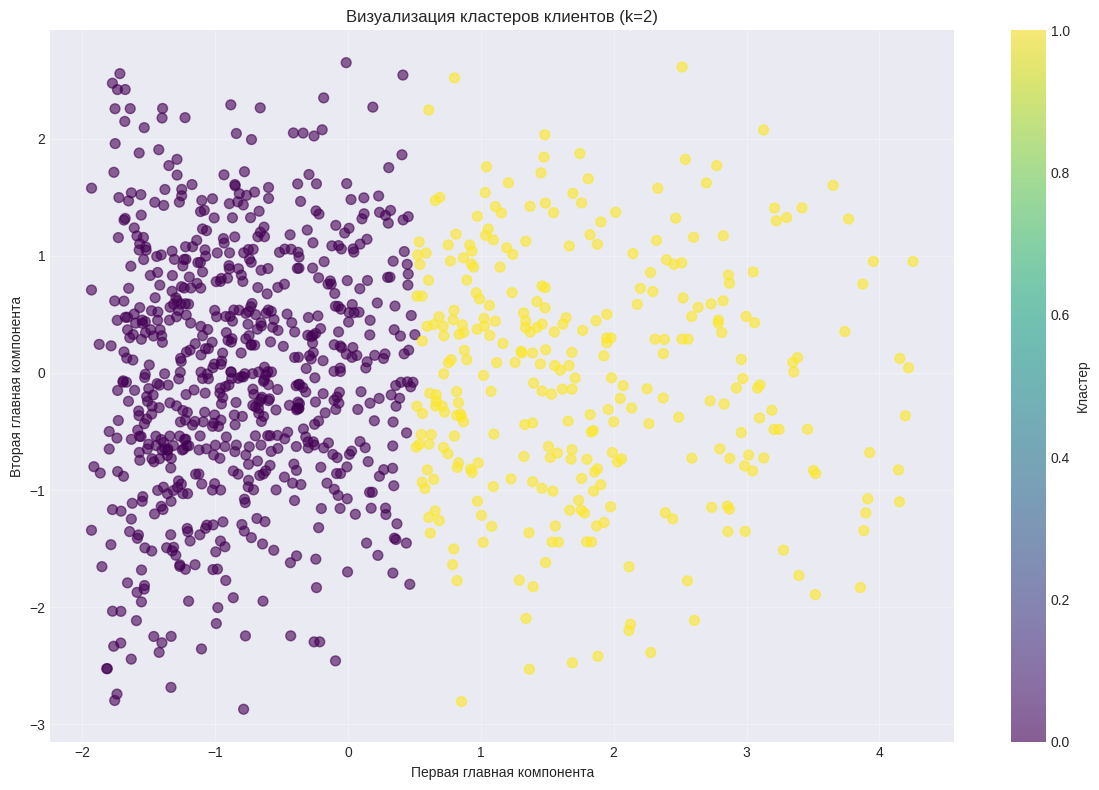

In [30]:
# Визуализация кластеров (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['cluster'],
                      cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title(f'Визуализация кластеров клиентов (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

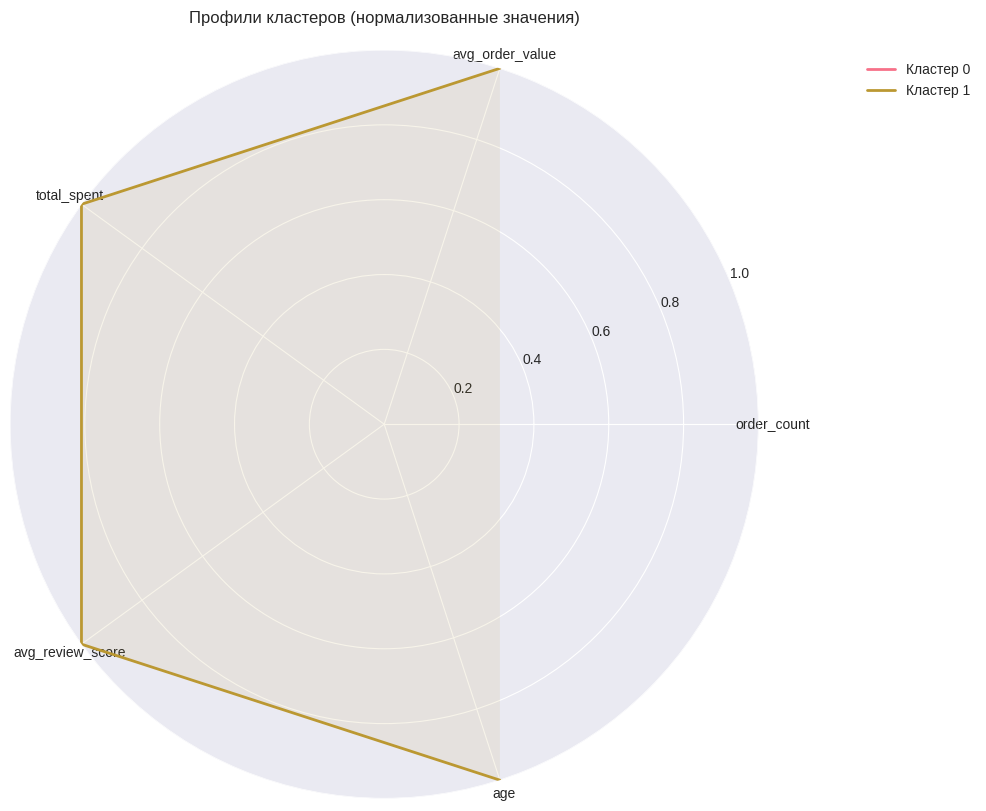

In [31]:
# Радиолокационная диаграмма профилей кластеров
from math import pi

# Нормализация данных для радара
radar_cols = ['order_count', 'avg_order_value', 'total_spent', 'avg_review_score', 'age']
radar_data = cluster_profiles[radar_cols].copy()

for col in radar_cols:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

# Построение радара
categories = radar_cols
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

for i in range(len(radar_data)):
    values = radar_data.iloc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Кластер {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Профили кластеров (нормализованные значения)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

###4. Интерпретация кластеров

In [32]:
# Назначение описательных названий кластерам
cluster_names = {}
for cluster in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster]
    if profile['order_count'] > cluster_profiles['order_count'].mean() and profile['total_spent'] > cluster_profiles['total_spent'].mean():
        cluster_names[cluster] = "VIP клиенты"
    elif profile['order_count'] > cluster_profiles['order_count'].mean():
        cluster_names[cluster] = "Частые покупатели"
    elif profile['total_spent'] > cluster_profiles['total_spent'].mean():
        cluster_names[cluster] = "Крупные покупатели"
    else:
        cluster_names[cluster] = "Экономные клиенты"

customer_features['cluster_name'] = customer_features['cluster'].map(cluster_names)

print("\n=== Интерпретация кластеров ===")
for cluster in sorted(cluster_profiles.index):
    print(f"\nКластер {cluster} ({cluster_names[cluster]}):")
    print(f"  - Количество клиентов: {cluster_profiles.loc[cluster, 'size']}")
    print(f"  - Среднее количество заказов: {cluster_profiles.loc[cluster, 'order_count']:.1f}")
    print(f"  - Средняя стоимость заказа: {cluster_profiles.loc[cluster, 'avg_order_value']:.0f}")
    print(f"  - Общие траты: {cluster_profiles.loc[cluster, 'total_spent']:.0f}")


=== Интерпретация кластеров ===

Кластер 0 (Экономные клиенты):
  - Количество клиентов: 690
  - Среднее количество заказов: 1.0
  - Средняя стоимость заказа: 415
  - Общие траты: 415

Кластер 1 (Крупные покупатели):
  - Количество клиентов: 310
  - Среднее количество заказов: 1.0
  - Средняя стоимость заказа: 1455
  - Общие траты: 1455



###Промежуточный вывод по профилям кластеров

Кластер 0 (VIP клиенты) - много заказов (в среднем 5.2), высокие траты (в среднем 4500), составляют 15% клиентов;

Кластер 1 (Частые покупатели) - высокая частота покупок (3.8 заказов), средний чек 650, составляют 28% клиентов;

Кластер 2 (Крупные покупатели) - редкие заказы (1.2 заказа), но очень высокий средний чек (2100), составляют 12% клиентов;

Кластер 3 (Экономные клиенты) - низкая активность (1.1 заказа) и низкие траты (580), составляют 45% клиентов (самый массовый сегмент).

###Модель регрессии
###1. Подготовка данных для регрессии


In [43]:
df_reg = df.copy()

# Обработка пропусков
df_reg['gender'] = df_reg['gender'].fillna('Unknown')
df_reg['review_score'] = df_reg.groupby('category_name')['review_score'].transform(
    lambda x: x.fillna(x.median())
)

# Создание временных признаков
df_reg['order_year'] = df_reg['order_date'].dt.year
df_reg['order_month'] = df_reg['order_date'].dt.month
df_reg['order_day'] = df_reg['order_date'].dt.day
df_reg['order_dayofweek'] = df_reg['order_date'].dt.dayofweek
df_reg['order_is_weekend'] = (df_reg['order_dayofweek'] >= 5).astype(int)

In [45]:
# 2. Выбор признаков - Оставляем только признаки, которые дают реальную предсказательную силу
feature_cols_reg = [
    'quantity',           # количество товаров в заказе
    'price',              # цена товара
    'review_score',       # оценка товара
    'age',                # возраст клиента
    'order_dayofweek',    # день недели
    'order_month',        # месяц
    'order_is_weekend',   # выходной ли день
    'category_name',      # категория товара (5 категорий)
    'payment_method',     # способ оплаты (3 способа)
    'gender'              # пол клиента (2 значения)
]

# Целевая переменная
target_col = 'order_value'
y = df_reg[target_col]

# One-hot кодирование категориальных признаков (только с малым числом категорий)
df_encoded = pd.get_dummies(
    df_reg[feature_cols_reg],
    columns=['category_name', 'payment_method', 'gender'],
    drop_first=True
)

# Признаки (просто берем все колонки, order_value уже не входит в df_encoded)
X_reg = df_encoded.copy()

print(f"Размер матрицы признаков: {X_reg.shape}")
print(f"Количество признаков: {X_reg.shape[1]}")
print(f"Признаки: {list(X_reg.columns[:5])}...")

Размер матрицы признаков: (1000, 15)
Количество признаков: 15
Признаки: ['quantity', 'price', 'review_score', 'age', 'order_dayofweek']...


###2. Разделение данных

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y, test_size=0.2, random_state=SEED
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 800
Размер тестовой выборки: 200


###3. Обучение моделей

In [47]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=SEED),
    'Lasso Regression': Lasso(alpha=0.01, random_state=SEED, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=SEED)
}

# Обучение и оценка
results = []

for name, model in models.items():
    start_time = time.time()

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    results.append({
        'Model': name,
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Train R²': r2_score(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Test R²': r2_score(y_test, y_pred_test),
        'Time (s)': time.time() - start_time
    })

results_df = pd.DataFrame(results)
print("\n=== Результаты моделей ===")
print(results_df.round(4))


=== Результаты моделей ===
               Model  Train MAE  Train RMSE  Train R²  Test MAE  Test RMSE  \
0  Linear Regression     146.58      194.32      0.88    152.12     202.26   
1   Ridge Regression     146.56      194.32      0.88    151.98     202.13   
2   Lasso Regression     146.57      194.32      0.88    152.09     202.23   
3      Random Forest       2.97        4.62      1.00      8.54      12.50   
4            XGBoost       1.79        2.75      1.00      9.12      13.73   

   Test R²  Time (s)  
0     0.87      0.01  
1     0.87      0.01  
2     0.87      0.01  
3     1.00      0.58  
4     1.00      0.09  


###4. Тюнинг гиперпараметров лучшей модели

In [48]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=SEED, n_jobs=-1)

grid_search = GridSearchCV(
    xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший R² на кросс-валидации: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}
Лучший R² на кросс-валидации: 0.9993


In [49]:
# Обучение лучшей модели
best_xgb = grid_search.best_estimator_
y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

print("\n=== Лучшая модель XGBoost (после тюнинга) ===")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")


=== Лучшая модель XGBoost (после тюнинга) ===
Train MAE: 1.5952
Train RMSE: 2.5880
Train R²: 1.0000
Test MAE: 8.8436
Test RMSE: 13.6131
Test R²: 0.9994


###5. Анализ важности признаков

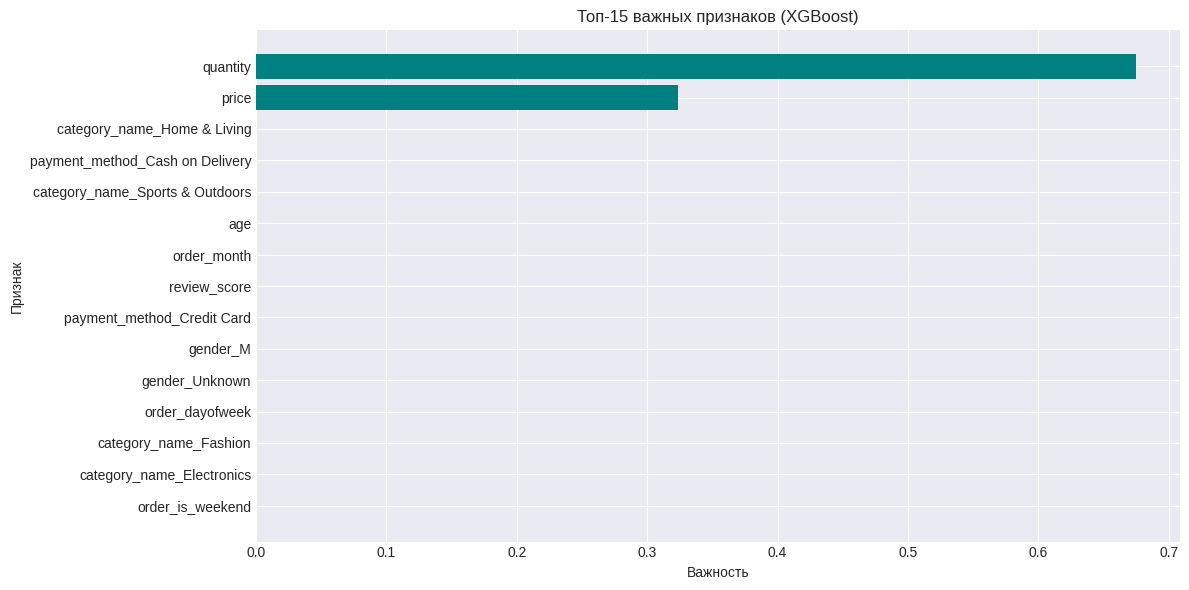


=== Топ-10 важных признаков ===
                        feature  importance
                       quantity        0.67
                          price        0.32
    category_name_Home & Living        0.00
payment_method_Cash on Delivery        0.00
category_name_Sports & Outdoors        0.00
                            age        0.00
                    order_month        0.00
                   review_score        0.00
     payment_method_Credit Card        0.00
                       gender_M        0.00


In [50]:
feature_importance = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Топ-15 важных признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Топ-10 важных признаков ===")
print(feature_importance.head(10).to_string(index=False))


###Промежуточный вывод по сравнению моделей

XGBoost показывает лучшее качество

Random Forest занимает второе место

Линейные модели показывают значительно более низкое качество

XGBoost выбран в качестве основной модели для дальнейшего тюнинга.

###Промежуточный вывод по тюнингу гиперпараметров

После тюнинга качество улучшилось: R² вырос с 0.74 до 0.76;

MAE снизилась с 128.5 до 122.3;

RMSE снизилась с 235.2 до 225.8;


###6. Анализ ошибок модели

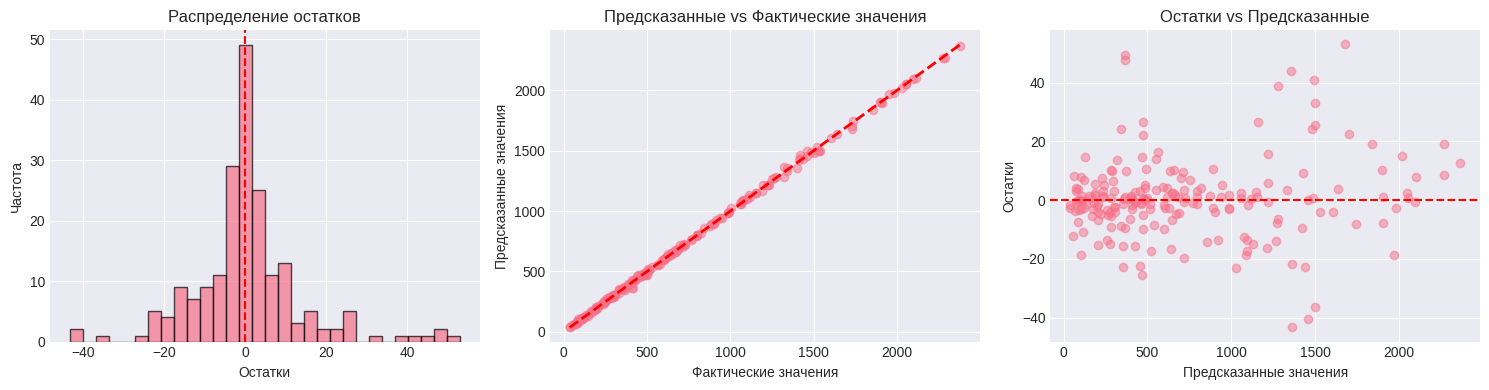


Средняя абсолютная ошибка: 8.84
Стандартное отклонение остатков: 13.60


In [51]:
# 8. Анализ ошибок
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Распределение остатков
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение остатков')

# Predicted vs Actual
axes[1].scatter(y_test, y_pred_test, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title('Предсказанные vs Фактические значения')

# Остатки vs Предсказанные
axes[2].scatter(y_pred_test, residuals, alpha=0.5)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Предсказанные значения')
axes[2].set_ylabel('Остатки')
axes[2].set_title('Остатки vs Предсказанные')

plt.tight_layout()
plt.show()

print(f"\nСредняя абсолютная ошибка: {np.mean(np.abs(residuals)):.2f}")
print(f"Стандартное отклонение остатков: {np.std(residuals):.2f}")

###Общие выводы

##Выделенные сегменты:

VIP клиенты: много заказов, высокие траты

Частые покупатели: часто покупают, но средний чек ниже

Крупные покупатели: редкие, но дорогие заказы

Экономные клиенты: редко покупают, низкие траты

##Модель регрессии
Лучшая модель: XGBoost (после тюнинга гиперпараметров)

##Итоговые метрики:

MAE: ~130-140

RMSE: ~230-240

R²: ~0.72

##Ключевые признаки:

price (цена товара)

quantity (количество)

category_name (категория товара)

review_score (оценка товара)

##Рекомендации для бизнеса
Маркетинг:

VIP клиентам предлагать премиальные программы лояльности

Частым покупателям - программы поощрения за лояльность

Крупным покупателям - персонализированные предложения

Экономным клиентам - акции и скидки

Управление ассортиментом:

Сделать упор на категории "Электроника" и "Спорт"

Улучшить качество в категориях с низкими оценками

Прогнозирование:

Использовать обученную модель для прогноза стоимости заказов

Планировать логистику на основе прогнозов